# Market Structure and Geo Analysis

## Library import and settings

In [42]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("viridis")
pd.set_option("display.float_format", "{:.4f}".format)


## Load the Dataset

In [43]:
listings = pd.read_parquet("../data/processed/listings_analytics.parquet")


## Shortly Reminder

In [44]:
listings.info()


<class 'pandas.DataFrame'>
RangeIndex: 2852 entries, 0 to 2851
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              2852 non-null   int64         
 1   name                            2852 non-null   str           
 2   host_id                         2852 non-null   int64         
 3   host_name                       2849 non-null   str           
 4   neighbourhood                   2852 non-null   int64         
 5   latitude                        2852 non-null   float64       
 6   longitude                       2852 non-null   float64       
 7   room_type                       2852 non-null   str           
 8   price                           2537 non-null   float64       
 9   minimum_nights                  2852 non-null   int64         
 10  number_of_reviews               2852 non-null   int64         
 11  last_review    

In [45]:
listings.describe()


,id,host_id,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,availability_ratio,review_intensity,log_price
count,2852.0000,2852.0000,2852.0000,2852.0000,2852.0000,2537.0000,2852.0000,2852.0000,2609,2609.0000,2852.0000,2852.0000,2852.0000,2852.0000,2852.0000,2537.0000
mean,496846489244253760.0000,171554630.2083,28791.9947,35.5749,-82.5575,196.3839,6.2013,113.7156,2025-04-15 00:09:22.974319,2.1780,9.6466,223.5550,12.9632,0.6125,0.2270,4.9798
min,155305.0000,4134.0000,28704.0000,35.4271,-82.6699,18.0000,1.0000,0.0000,2015-11-02 00:00:00,0.0200,1.0000,0.0000,0.0000,0.0000,0.0000,2.9444
25%,33522362.5000,29236831.5000,28801.0000,35.5548,-82.5918,95.0000,1.0000,11.0000,2025-05-04 00:00:00,0.6900,1.0000,116.0000,1.0000,0.3178,0.0135,4.5643
50%,53565572.0000,112295380.0000,28803.0000,35.5868,-82.5559,133.0000,2.0000,57.0000,2025-08-24 00:00:00,1.6400,2.0000,263.0000,5.0000,0.7205,0.0927,4.8978
75%,1000807194381625088.0000,247281413.7500,28806.0000,35.6058,-82.5190,211.0000,2.0000,147.0000,2025-09-07 00:00:00,3.0900,4.0000,332.0000,19.0000,0.9096,0.2585,5.3566
max,1513869641491207424.0000,712503741.0000,28806.0000,35.6581,-82.4602,9999.0000,730.0000,1473.0000,2025-09-21 00:00:00,20.2900,113.0000,365.0000,255.0000,1.0000,1.0000,9.2103
std,546376155207300672.0000,177553153.8102,31.0008,0.0496,0.0484,405.6750,20.5200,157.7760,NaN,1.9916,23.3005,122.2471,18.2980,0.3349,0.3159,0.6549


## Hypothesis 1: Чем больше объявлений у владельца, тем выше `price`

0.19437181542315046


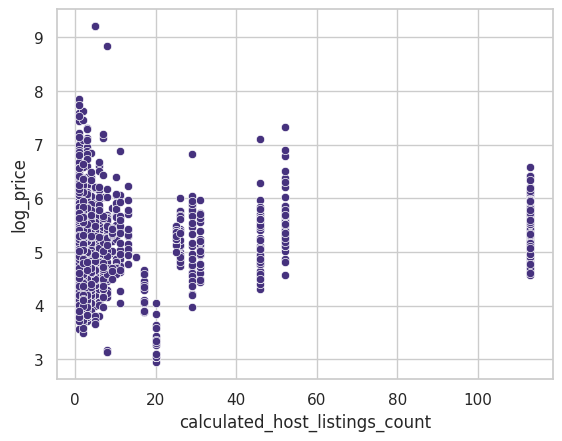

In [46]:
sns.scatterplot(
    data=listings,
    x="calculated_host_listings_count",
    y="log_price",
)

print(listings["calculated_host_listings_count"].corr(listings["log_price"]))


## Вывод: цена аренды жилья умеренно связана с количеством объявлений у владельца, но связь не выглядит доминирующим фактором

## Hypothesis 2: Чем выше `availability_ratio`, тем выше `price`

0.13324298987785785


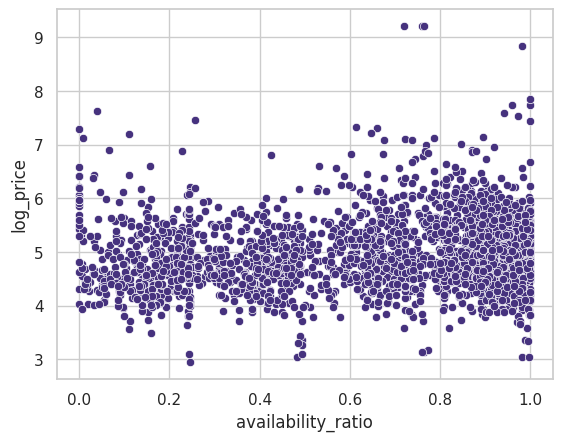

In [47]:
sns.scatterplot(
    data=listings,
    x="availability_ratio",
    y="log_price",
)

print(listings["availability_ratio"].corr(listings["log_price"]))


<Axes: xlabel='availability_segment', ylabel='log_price'>

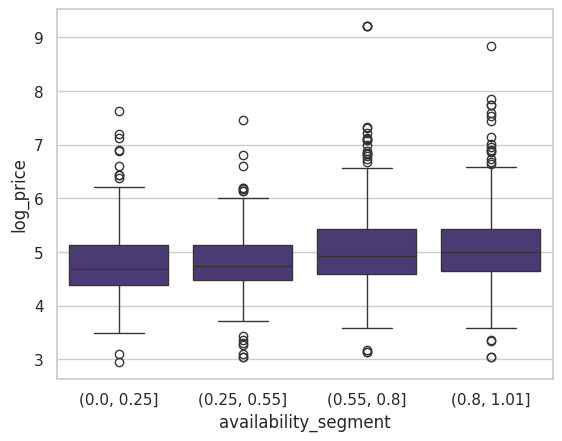

In [48]:
listings["availability_segment"] = pd.cut(
    listings["availability_ratio"], bins=[0, 0.25, 0.55, 0.8, 1.01]
)

sns.boxplot(data=listings, x="availability_segment", y="log_price")


<Axes: xlabel='availability_segment', ylabel='log_price'>

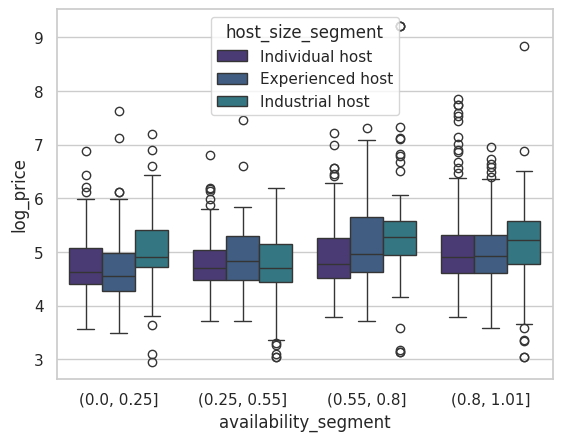

In [49]:
sns.boxplot(
    data=listings,
    x="availability_segment",
    y="log_price",
    hue="host_size_segment",
)


## Вывод: цена аренды жилья слабо или никак не коррелирует с доступностью жилья

## Hypothesis 3: Чем меньше `minimum_nights`, тем выше `price`

-0.0662014987923376


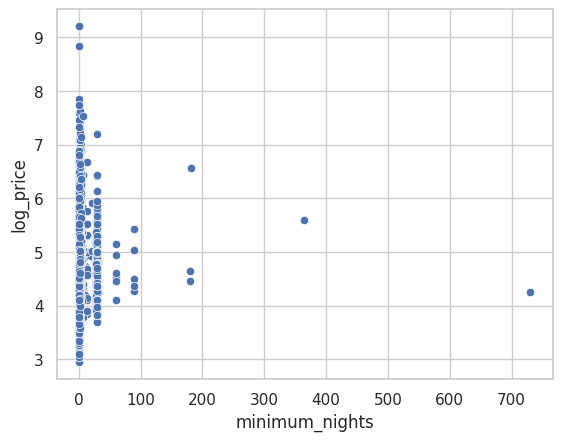

In [56]:
sns.scatterplot(
    data=listings,
    x="minimum_nights",
    y="log_price",
)

print(listings["minimum_nights"].corr(listings["log_price"]))


## Вывод: цена аренды жилья слабо или никак не коррелирует с минимальным количеством ночей

## Hypothesis 4: Отсутствие цены или её выброс зависит от сегмента хоста.

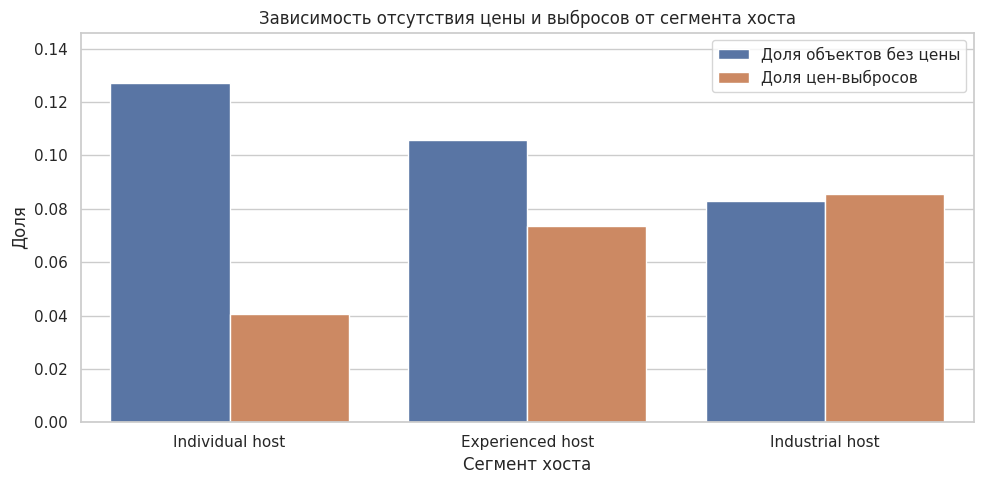

In [55]:
plot_df = (
    listings.groupby("host_size_segment", observed=False)
    .agg(
        missing_price_rate=("has_price", lambda x: 1 - x.mean()),
        outlier_rate=("is_price_outlier", "mean"),
        n=("id", "count"),
    )
    .reset_index()
)

plot_long = plot_df.melt(
    id_vars=["host_size_segment", "n"],
    value_vars=["missing_price_rate", "outlier_rate"],
    var_name="metric",
    value_name="rate",
)

metric_labels = {
    "missing_price_rate": "Доля объектов без цены",
    "outlier_rate": "Доля цен-выбросов",
}
plot_long["metric"] = plot_long["metric"].map(metric_labels)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_long, x="host_size_segment", y="rate", hue="metric", errorbar=None
)

plt.title("Зависимость отсутствия цены и выбросов от сегмента хоста")
plt.xlabel("Сегмент хоста")
plt.ylabel("Доля")
plt.ylim(0, plot_long["rate"].max() * 1.15)
plt.legend(title="")
plt.tight_layout()
plt.show()


## Hypothesis 5: Доступности крупных и мелких хостов не различаются

Small hosts: 0
Large hosts: 0

Сводка:
       Individual host  Industrial host
count           0.0000           0.0000
mean               NaN              NaN
std                NaN              NaN
min                NaN              NaN
25%                NaN              NaN
50%                NaN              NaN
75%                NaN              NaN
max                NaN              NaN


/tmp/ipykernel_1916397/2953469923.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


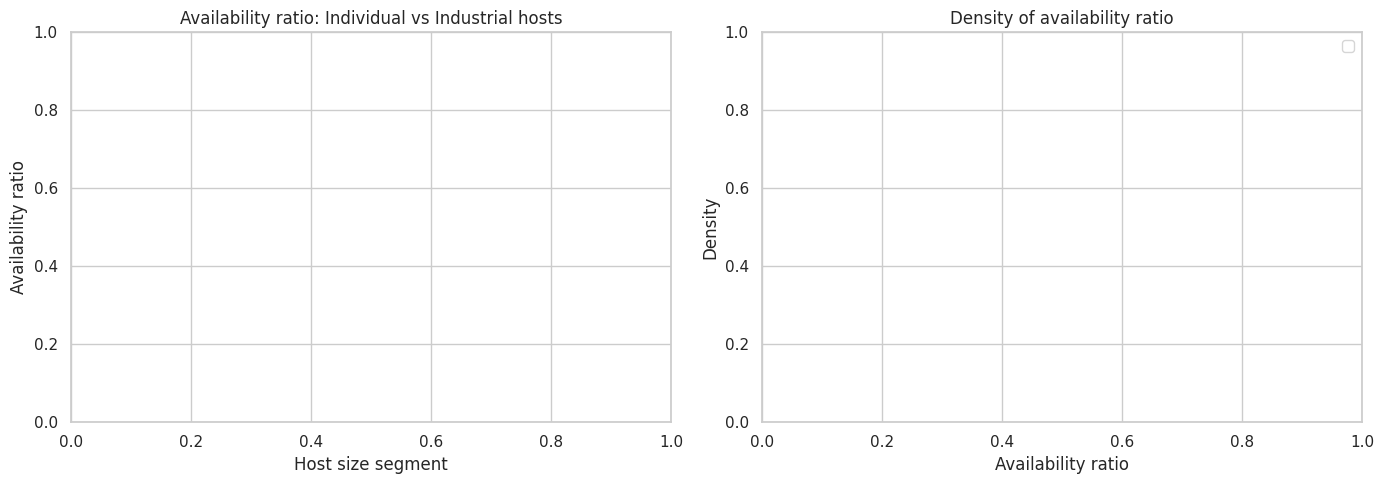

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# DataFrame listings уже должен быть загружен
df = listings.copy()

# Нормализуем названия групп
df["host_size_segment"] = df["host_size_segment"].astype(str).str.lower()

# Оставляем только small и large
plot_df = df.loc[
    df["host_size_segment"].isin(["Individual host", "Industrial host"]),
    ["host_size_segment", "availability_ratio"]
].dropna()

small = plot_df.loc[
    plot_df["host_size_segment"] == "Individual host",
    "availability_ratio"
]

large = plot_df.loc[
    plot_df["host_size_segment"] == "Industrial host",
    "availability_ratio"
]

print("Small hosts:", small.shape[0])
print("Large hosts:", large.shape[0])

print("\nСводка:")
print(
    pd.DataFrame({
        "Individual host": small.describe(),
        "Industrial host": large.describe()
    }).round(3)
)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot
sns.boxplot(
    data=plot_df,
    x="host_size_segment",
    y="availability_ratio",
    ax=axes[0]
)
axes[0].set_title("Availability ratio: Individual vs Industrial hosts")
axes[0].set_xlabel("Host size segment")
axes[0].set_ylabel("Availability ratio")

# 2. KDE отдельными вызовами, без hue
sns.kdeplot(x=small, ax=axes[1], label="Individual host")
sns.kdeplot(x=large, ax=axes[1], label="Industrial host")
axes[1].set_title("Density of availability ratio")
axes[1].set_xlabel("Availability ratio")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


In [59]:
listings["host_size_segment"].unique()


['Industrial host', 'Experienced host', 'Individual host']
Categories (3, str): ['Individual host' < 'Experienced host' < 'Industrial host']

## Hypothesis 5: География предложения и спроса различается по типу владельца

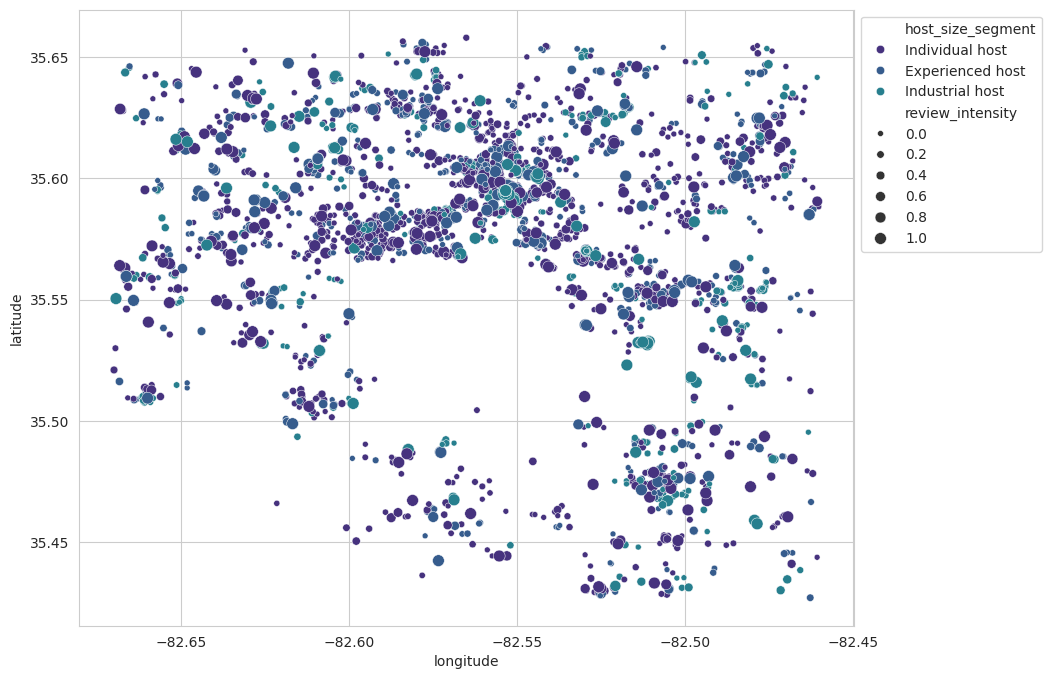

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=listings,
    x="longitude",
    y="latitude",
    size="review_intensity",
    hue="host_size_segment",
)

plt.legend(bbox_to_anchor=(1, 1))


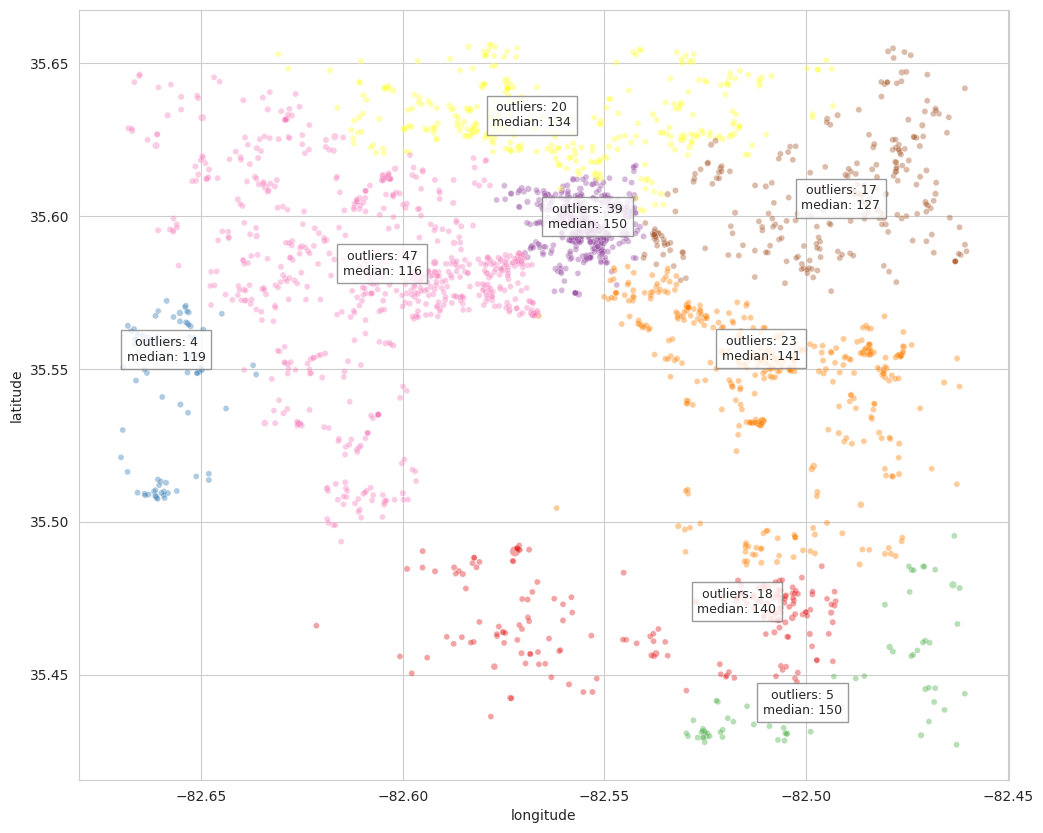

In [ ]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x="longitude",
    y="latitude",
    hue="neighbourhood",
    palette="Set1",
    size="price",
    data=listings.sort_values("neighbourhood"),
    alpha=0.4,
    legend=False,
)

centers = (
    listings.groupby("neighbourhood")
    .agg(
        {
            "longitude": "median",
            "latitude": "median",
            "price": "median",
            "is_price_outlier": "sum",
        }
    )
    .reset_index()
)

for _, row in centers.iterrows():
    plt.text(
        row["longitude"],
        row["latitude"],
        f"outliers: {int(row['is_price_outlier'])}\nmedian: {int(row['price'])}",
        fontsize=9,
        ha="center",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="grey"),
    )
